# Imports

In [56]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

# Data Collection

I compiled season-level player statistics from the 2000–2001 season through the 2024-2025 season, including basic statistics (points, rebounds, assists, steals, blocks, etc.) and advanced statistics (True Shooting %, Usage Rate, Win Shares per 48, BPM, VORP, etc.).

Both basic and advanced statistics were gathered from the Basketball Reference website. Seasons in which players logged fewer than 10 minutes per game or played fewer than 20 games were excluded to remove players who did not make meaningful contributions and to limit outliers. (e.g., Jamal Crawford in the 2019-2020 season, where he has a BPM of 15.0 but only has a single game played) 


In [57]:
# Get simple stats from 2000-2001 season to 2024-2025 season
normal_stats_df = pd.read_csv("normal_stats.csv")

In [58]:
# Get advanced stats from the 2000-2001 season to the 2024-2025 season
advanced_stats_df = pd.read_csv("advanced_stats.csv")

# Config

The target variable is Box Plus/Minus (BPM). Basketball Reference describes it as a score-based metric that estimates a basketball player’s contribution in points above league average (0.0) per 100 possessions played. 

BPM is chosen as our target variable because it is a composite statistic that combines both offensive and defensive contributions, giving a more balanced evaluation of a player’s performance and value. Unlike other basic metrics that only measure one aspect of the game, such as PPG (Points per Game) only measuring scoring output, or TS% (True Shooting Percentage) only measuring scoring efficiency, BPM combines multiple aspects of a player’s performance into a single number. 

While this has its deficiencies, such as not being specific enough and sometimes being inaccurate, it is a very easy stat to work with and interpret, which is also partially why it was chosen.

In [59]:
target = "BPM_next"
base_cols = ['Player','Age','Season','BPM','PTS','MP', 'G','FGA','FG%','3PA','3P%','FT','FTA','TS%','ORB','DRB','TRB',
             'AST','STL','BLK','TOV','PER','FTr','3PAr','USG%','WS/48','VORP','PPM','eFG%']
min_minutes = 10    # Filter out seasons where players don't play significant minutes
min_games = 20      # Filter out seasons where players don't play in significant number of games
lags = (1,2,3)      # Creates copies of stats shifted back by x number of seasons
rolls = (2,3)       # Creates rolling averages over the last x number of seasons
ewm_halflife = 3    # Exponentially weighted means, with a half life of 3. (Season from 2020-2021 carries half the weight as 2023-2024)

# Data Cleaning

The raw data required several cleaning steps before merging.

Basketball Reference uses 3 rows for players that have been traded mid-season. One row for the team they were traded from, one row for the team they were traded to, and one row for the cumulative stats. We opt to only keep the row with the cumulative stats, and this is done by sorting on the games played column, and only selecting the first row. 

Columns such as rankings and awards are also dropped as they are not useful for regression. We add the Points Per Minute (PPM) column as it could be significant in regression. 

Finally, the basic and advanced stats are merged on Player and Season, and any remaining columns not in our base feature set are dropped.

In [60]:
# Only keep the total stats for players on multiple teams in a single season
normal_stats_df = normal_stats_df.sort_values('G', ascending=False)
normal_stats_df = normal_stats_df.groupby(['Player', 'Season'], as_index=False).first()

In [61]:
# Drops redundant columns
normal_stats_df.drop(['Rk', 'Awards', 'Player-additional', 'Team', '2P', '2PA', '2P%', 'GS', 'Pos'], axis=1, inplace=True, errors='ignore')

In [62]:
# We add some columns that will help our analysis
normal_stats_df["PPM"] = normal_stats_df.get("PTS") / normal_stats_df.get("MP") # Points per minute

In [63]:
# Only keep the total stats for players on multiple teams in a single season
advanced_stats_df = advanced_stats_df.sort_values('G', ascending=False)
advanced_stats_df = advanced_stats_df.groupby(['Player', 'Season'], as_index=False).first()

In [64]:
# Drops redundant columns
advanced_stats_df.drop(['Rk', 'Team', 'G', 'GS', 'MP', 'Awards', 'Player-additional'], axis=1, inplace=True)

In [65]:
nba_stats = normal_stats_df.merge(advanced_stats_df, on = ['Player', 'Season'])

In [66]:
nba_stats.drop(['WS', 'ORB%', 'DRB%', 'OWS', 'DWS', 'OBPM', 'DBPM'], axis=1, inplace=True)

In [67]:
have = [c for c in base_cols if c in nba_stats.columns]
nba_stats = nba_stats[have].copy()

# Feature Engineering

To predict future performance, we recognize that simply taking an average of all past seasons would result in inaccurate data. Hence, I engineered temporal features using lag features, rolling means, and exponentially weighted means to better contextualize the basic features. By doing this, we create diverse features with no leakage of future season values into the past.

Lag features represent a player’s statistics from the previous seasons, carried forward as predictors of the next season’s performance. They help capture both year-to-year continuity and sudden shifts in production.

Rolling averages take the mean of a player’s stats over the last seasons, reducing year-to-year noise. They highlight sustained trends such as steady improvement or gradual decline, rather than short-term fluctuations.

Exponentially Weighted Means (EWM) aggregates the features throughout a player’s entire career up to the current season. They weigh recent seasons more heavily while still incorporating players’ full playing history, allowing the model to balance long-term performance with recency. 

While these temporal features have similarities, each provides a distinct perspective: lag features capture short-term momentum, rolling averages highlight medium-term trends, and exponentially weighted means emphasize long-term consistency. Together, they effectively complement each other in regression models to provide a more comprehensive view of player performance statistics.


In [ ]:
def next_season(season):
    """Given a season string like '2022-23', returns '2023-24'."""
    if pd.isna(season): return season
    y = int(str(season)[:4]); return f"{y+1}-{(y+2)%100:02d}"

# Find which players played the next season
pairs = (
    nba_stats
      .assign(Next_Season=lambda d: d['Season'].map(next_season))
      .merge(
          nba_stats[['Player','Season']].rename(columns={'Season':'Next_Season'}),
          on=['Player','Next_Season'],
          how='inner',
          validate='many_to_one'
      )
)

# Set the next season as target
next_targets = (
    nba_stats
      .rename(columns={'Season':'Next_Season'})
      .rename(columns={c: f'{c}_next' for c in nba_stats.columns if c not in ['Player','Next_Season']})
)
played = pairs.merge(
    next_targets[['Player','Next_Season'] + [c for c in next_targets.columns if c.endswith('_next')]],
    on=['Player','Next_Season'], how='left'
)

# Filter out seasons with too few games/minutes (from config)
if 'MP' in played.columns:
    played = played.loc[(played['MP'] >= min_minutes) & (played['G'] >= min_games)].copy()

played['Year'] = played['Season'].str[:4].astype(int)
played = played.sort_values(['Player','Year','Season']).reset_index(drop=True)

# Builds historical features for each season stat
hist = (
    nba_stats.copy()
      .assign(Year=lambda d: d['Season'].str[:4].astype(int))
      .sort_values(['Player','Year','Season'])
)
num_cols = [c for c in hist.columns if c not in ['Player','Season']]

def add_lags(df, cols, lags=(1,2,3)):
    """
    For each column in cols, create lagged copies shifted back by each value in lags.
    (e.g. BPM_lag1 = last season's BPM, BPM_lag2 = two seasons ago, etc.)
    """
    out = df.copy()
    g = out.groupby('Player', group_keys=False)
    for L in lags:
        out[[f'{c}_lag{L}' for c in cols]] = g[cols].shift(L)
    return out

def add_rolls_past_only(df, cols, windows=(2,3)):
    """
    For each column in cols, creates rolling averages over the previous w seasons for each window w in windows. 
    shift(1) is applied since we don't use the current season. 
    min_periods=1 allows players with fewer seasons than the window to still get a value rather than NaN.
    """
    out = df.copy()
    g = out.groupby('Player', group_keys=False)
    for w in windows:
        out[[f'{c}_roll{w}' for c in cols]] = g[cols].apply(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
    return out

def add_career_features(df, cols, halflife=3):
    """
    For each column in cols, creates three cumulative features:
      - career_mean: simple average of all prior seasons
      - career_sum: cumulative sum of all prior seasons
      - career_ewm: exponentially weighted mean, weighting recent seasons more heavily
    Similar to the previous function, shift(1) is utilized
    halflife controls the decay rate of the EWM (see config for example).
    """
    out = df.copy()
    g = out.groupby('Player', group_keys=False)
    out[[f'{c}_career_mean' for c in cols]] = g[cols].apply(lambda s: s.shift(1).expanding().mean())
    out[[f'{c}_career_sum'  for c in cols]] = g[cols].apply(lambda s: s.shift(1).expanding().sum())
    out[[f'{c}_career_ewm'  for c in cols]] = g[cols].apply(lambda s: s.shift(1).ewm(halflife=halflife, min_periods=1).mean())
    return out

hist = add_lags(hist, num_cols, lags=lags)
hist = add_rolls_past_only(hist, num_cols, windows=rolls)
hist = add_career_features(hist, num_cols, halflife=ewm_halflife)
feat_hist = hist.add_prefix('hist_')

# Merge features into the dataframe from Step 1 (played)

played = (
    played.merge(
        feat_hist,
        left_on=['Player','Season'],
        right_on=['hist_Player','hist_Season'],
        how='left'
    )
    .drop(columns=['hist_Player','hist_Season'], errors='ignore')
    .reset_index(drop=True)
)

# Feature/Target cols
feature_cols = [c for c in played.columns if c.startswith('hist_')]
target_cols  = [c for c in played.columns if c.endswith('_next')]

model_df = played.dropna(subset=target_cols).copy()

X = model_df[feature_cols]
y = model_df[target_cols]

keep_keywords = ["lag1", "lag2", "lag3", "roll2", "roll3", "career_ewm"]

def filter_features(df):
    keep_cols = []
    for col in df.columns:
        if any(kw in col for kw in keep_keywords):
            keep_cols.append(col)
    return df[keep_cols]

X = filter_features(X)

played = model_df.reset_index(drop=True)
played

,Player,Season,BPM,PTS,MP,G,FGA,FG%,3PA,3P%,...,hist_TOV_career_ewm,hist_PER_career_ewm,hist_FTr_career_ewm,hist_3PAr_career_ewm,hist_USG%_career_ewm,hist_WS/48_career_ewm,hist_VORP_career_ewm,hist_PPM_career_ewm,hist_eFG%_career_ewm,hist_Year_career_ewm
0,A.J. Green,2023-24,-2.1,4.5,11.0,56,3.5,0.423,3.0,0.408,...,0.3,11.5,0.032,0.840,16.6,0.111,0.1,0.444444,0.600,2022.0
1,A.J. Guyton,2000-01,-4.0,6.0,19.1,33,5.8,0.406,2.1,0.391,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A.J. Guyton,2001-02,-1.6,5.4,13.5,45,5.4,0.361,2.7,0.374,...,0.7,10.3,0.094,0.359,16.5,0.020,-0.3,0.314136,0.477,2000.0
3,A.J. Price,2009-10,-0.5,7.3,15.4,56,6.3,0.410,3.1,0.345,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A.J. Price,2010-11,-2.9,6.5,15.9,50,6.4,0.356,3.0,0.275,...,1.1,14.0,0.212,0.492,22.7,0.065,0.3,0.474026,0.494,2009.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7249,Óscar Torres,2001-02,-2.7,6.0,16.5,65,5.2,0.396,1.9,0.294,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7250,Ömer Aşık,2011-12,-0.7,3.1,14.7,66,2.4,0.506,0.0,NaN,...,0.8,11.8,1.028,0.000,12.5,0.130,0.1,0.231405,0.553,2010.0
7251,Šarūnas Jasikevičius,2005-06,0.1,7.3,20.8,75,5.7,0.396,3.1,0.364,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7252,Žarko Čabarkapa,2003-04,-5.7,4.1,11.6,49,4.0,0.411,0.7,0.188,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


I implemented time-rolling cross-validation by separating all seasons into folds. In each fold, the model is trained on all seasons prior to year x and is tested on season x. This method preserves temporal order by preventing data from peeking into the future and compromising the regression. This provides a more reliable generalization of performance than standard cross-validation. Performance is averaged across folds and compared to the baseline. 

In [71]:
def time_rolling_splits(df, k=3):
    """
    Creates time-aware cross-validation splits. Always use past season data for training, and future season data for testing.
    Example: We have data from 2000-2001 to 2004-2005 and k = 2, then the folds are as follows:
        Fold 1: train 2000-2001 to 2002-2003, test 2003-2004
        Fold 2: train 2000-2001 to 2003-2004, test 2004-2005
    """
    df_f = df.sort_values(['Year','Season']).reset_index(drop=True)
    years = np.sort(df_f['Year'].unique()); k = min(k, len(years))
    splits = []
    for i in range(k):
        test_year = years[-k + i]
        tr_idx = np.where(df_f['Year'] <  test_year)[0] # Training set
        te_idx = np.where(df_f['Year'] == test_year)[0] # Testing set
        if len(tr_idx) and len(te_idx): splits.append((tr_idx, te_idx))
    return splits

def prefilter_by_spearman(df, features, target, top_k=60):
    """
    Quick filter down to the top_k most correlated features with the target using Spearman correlation.
    This is done in order to reduce computational cost before using the expensive SFS algorithm
    """
    num = df.select_dtypes(include='number')
    feats = [f for f in features if f in num.columns and f != target and not f.endswith('_next')]
    corr = num[feats + [target]].corr(method='spearman')[target].abs().dropna().drop(target, errors='ignore')
    top = corr.sort_values(ascending=False).index.tolist()[:top_k]
    return [f for f in feats if f in top]

def baseline_last_season(df, target="BPM_next", lag_col="hist_BPM_lag1"):
    """
    Simple baseline that predicts next season's BPM as the last season's BPM
    """
    mask = df[[target, lag_col]].notna().all(1)
    return mean_absolute_error(df.loc[mask, target], df.loc[mask, lag_col])

def prepare_features(df, feature_cols, target, add_flags=True):
    """
    Adds binary _missing flag columns for features with NaN values (e.g. rookies always missing lag2/lag3 features)
    Imputes remaining NaNs with column means
    Drops rows where the target is NaN
    """
    X = df[feature_cols].copy(); y = pd.to_numeric(df[target], errors='coerce')
    if add_flags:
        for c in list(X.columns):
            if X[c].isna().any(): X[c + "_missing"] = X[c].isna().astype(np.uint8) # _missing flag
    X = X.astype('float32')
    X_imp = pd.DataFrame(SimpleImputer(strategy="mean").fit_transform(X), columns=X.columns, index=X.index).astype('float32') # Cast to float32 for memory efficiency
    mask = y.notna()
    return X_imp.loc[mask].reset_index(drop=True), y.loc[mask].reset_index(drop=True)

# Modelling

In [72]:
def sfs_fast(df, features, model, target, max_features=10, n_splits=3):
    """
    Runs SFS to greedily select the best features.
    Starts with an empty set. Iteratively adds whichever remaining feature improves MAE the most until max_features are selected.

    Steps:
      1. Prefilter to top_k candidates via Spearman correlation to reduce compute cost
      2. Prepare features (impute NaNs, cast to float32) — no _missing flags here
         since SFS works on a reduced feature set and flags would add noise
      3. Run SFS using time-aware CV splits to prevent data leakage
      4. Return the names of the selected features
    """
    base = prefilter_by_spearman(df, features, target, top_k=max(20, max_features*4)) # Prefilter using function above
    if len(base) <= 1: return base
    X_imp, y = prepare_features(df, base, target, add_flags=False)  # Prepare features using function above
    df_cv = df.loc[y.index].assign(_row=np.arange(len(y))).sort_values(['Year','Season']).reset_index(drop=True)
    cv = time_rolling_splits(df_cv, k=n_splits) # Creating cross validation splits
    n_select = min(max_features, len(base)-1)
    sel = SequentialFeatureSelector(
        estimator=Pipeline([('model', model)]),
        direction='forward', n_features_to_select=n_select,
        scoring=make_scorer(mean_absolute_error, greater_is_better=False),
        cv=cv, n_jobs=1
    )
    sel.fit(X_imp, y)
    feat_names = X_imp.columns
    return list(feat_names[sel.get_support()])

In [73]:

def run_model(df, name, model, target='BPM_next', keep_extra=('MP',), max_features=10, k=3):
    """
    Runs SFS to select the best max_features features from all hist_ columns
    Prepares the feature matrix
    Trains and evaluates using time-aware cross validation splits
      
    Note that due to an attempt to reduce computational cost, this pipeline is not completely leakage-free.
    A fully leakage-free pipeline would ned to re-run SFS inside each fold, which is somewhat infeasible.
    """
    # Select the best features using SFS
    candidates = [c for c in df.columns if c.startswith('hist_')] + [c for c in keep_extra if c in df.columns]
    selected = sfs_fast(df, candidates, model, target, max_features=max_features, n_splits=k)
    
    # Utilizes the prepare_features function
    X_imp, y = prepare_features(df, selected, target, add_flags=True)
    
    # Train and evaluate using time-aware cross validation
    cv = time_rolling_splits(df.loc[y.index], k)
    maes = []
    for tr, te in cv:
        model.fit(X_imp.iloc[tr], y.iloc[tr])
        pred = model.predict(pd.DataFrame(X_imp.iloc[te], columns=X_imp.columns))
        maes.append(mean_absolute_error(y.iloc[te], pred))
    print(f"{name} {model.__class__.__name__}: MAE={np.mean(maes):.3f} | folds={np.round(maes,3)} | feats={len(selected)}")
    return selected, float(np.mean(maes)), np.array(maes)


For our baseline, I used a naïve predictor that assumes a player’s BPM in the following season will be identical to their BPM from their previous season.

In [74]:
print("Baseline (last season BPM):", baseline_last_season(played, target, "hist_BPM_lag1"))

Baseline (last season BPM): 2.0250970873786405


For our regression models, I selected XGBoost, LightGBM, and Random Forest. These models were selected due to their ability to effectively handle the complex, nonlinear relationships present in basketball statistics. Previous research has shown the effectiveness of using ensemble regression methods to capture non-linear dynamics and interactions, further justifying their use in this context.

XGBoost and LightGBM, as gradient boosting ensemble models, are highly efficient and capable of capturing complex, non-linear interactions between features. Random Forest, a bagging-based ensemble model, provides robustness through ensemble averaging, which reduces overfitting and offers interpretable feature importance. Using both boosting and bagging approaches enables a balanced evaluation of forecasting effectiveness across different ensemble strategies.

In [75]:
# XGB Regressor
xgb = XGBRegressor(n_estimators=300, max_depth=4, subsample=0.8, colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=123)
xgb_sel, xgb_mae, xgb_folds = run_model(played, "XGB", xgb, target=target, max_features=10, k=5)

XGB XGBRegressor: MAE=1.623 | folds=[1.482 1.657 1.638 1.602 1.738] | feats=10


In [76]:
# Light GBM Regressor
lgbm = LGBMRegressor(n_estimators=100, learning_rate=0.1, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=123, verbose=-1)
lgbm_sel, lgbm_mae, lgbm_folds = run_model(played, "LGBM", lgbm, target=target, max_features=10, k=5)

LGBM LGBMRegressor: MAE=1.497 | folds=[1.416 1.496 1.508 1.462 1.603] | feats=10


In [77]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=3, max_features="sqrt", n_jobs=-1, random_state=123)
rf_sel, rf_mae, rf_folds = run_model(played, "RF", rf, target=target, max_features=10, k=5)

RF RandomForestRegressor: MAE=1.471 | folds=[1.396 1.529 1.459 1.432 1.538] | feats=10


In [78]:
# Print selected features for each model
print("XGB features:", xgb_sel)
print("LGBM features:", lgbm_sel)
print("RF features (used):", rf_sel)

XGB features: ['hist_PER', 'hist_VORP', 'hist_BPM_lag1', 'hist_VORP_lag1', 'hist_BPM_lag2', 'hist_PER_lag3', 'hist_PER_roll2', 'hist_VORP_roll3', 'hist_VORP_career_mean', 'hist_BPM_career_ewm']
LGBM features: ['hist_FGA', 'hist_PER', 'hist_VORP', 'hist_BPM_lag1', 'hist_PER_lag1', 'hist_WS/48_lag1', 'hist_VORP_lag1', 'hist_VORP_lag3', 'hist_BPM_roll3', 'hist_VORP_career_ewm']
RF features (used): ['hist_PTS', 'hist_STL', 'hist_PER', 'hist_VORP', 'hist_PER_lag1', 'hist_PER_career_mean', 'hist_VORP_career_mean', 'hist_BPM_career_sum', 'hist_BPM_career_ewm', 'hist_PER_career_ewm']


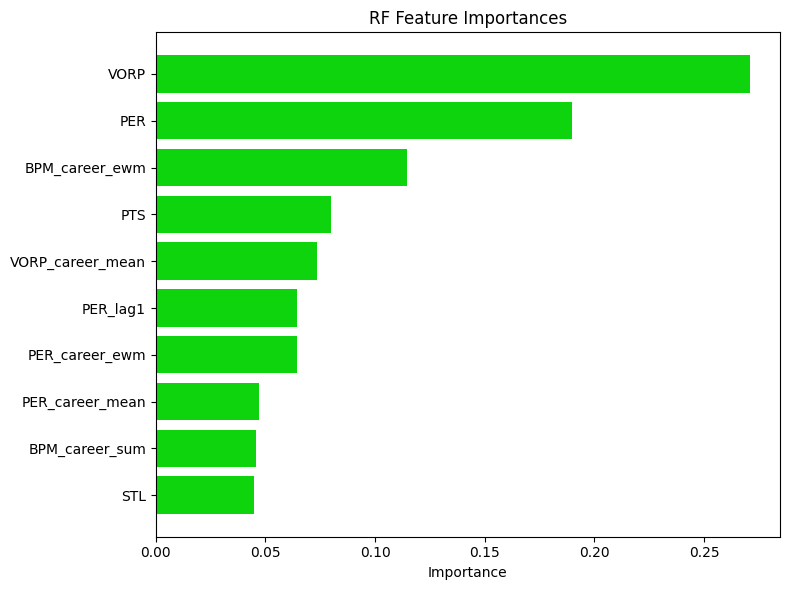

In [83]:
# Feature Importance Plot (using RF as it's the best model)
X_imp_rf, _ = prepare_features(played, rf_sel, target, add_flags=True)
feat_names_used = list(X_imp_rf.columns)
importances = rf.feature_importances_

importance_df = pd.DataFrame({'Feature': feat_names_used, 'Importance': importances})
importance_df = importance_df[~importance_df['Feature'].str.endswith('_missing')]  # drop missing flags
importance_df['Feature'] = importance_df['Feature'].str.replace('hist_', '', regex=False)  # strip hist_ prefix
importance_df = importance_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='#0dd40d')
ax.set_title('RF Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

For the Feature Importance plot, we use the Random Forest model since it was the top performer. The most important features are VORP, PER, their engineered versions, as well as the engineered versions of BPM. These are all composite statistics that already summarize overall player value, making their predictive power expected. PTS also makes an appearance, which is expected since scoring output is the thing most correlated with player performance from a non-statistical standpoint.

Somewhat surprising is the presence of STL (steals), which is not typically associated with overall player value as strongly as points, rebounds, or assists. Its appearance suggests that defensive activity, even when measured by a single basic stat, carries meaningful signal in predicting future BPM.

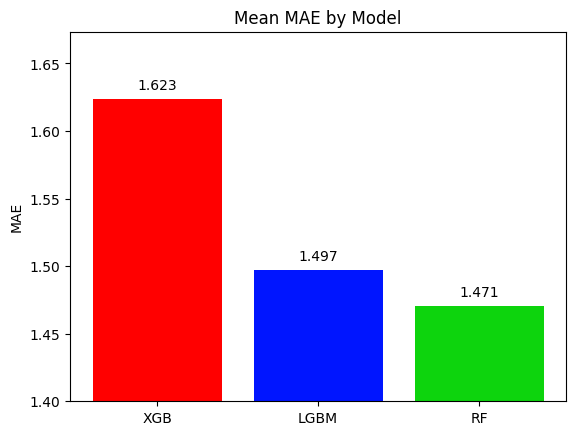

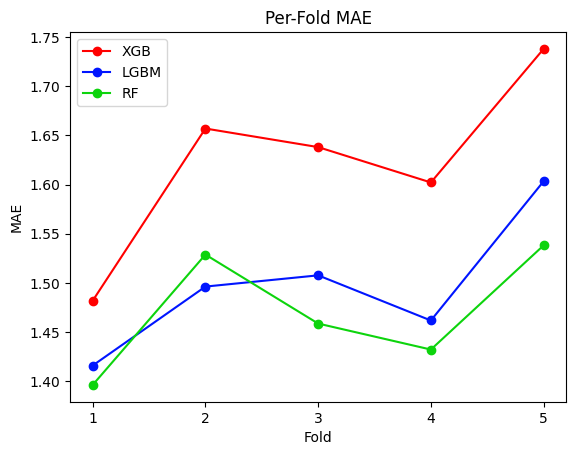

In [79]:
model_names = ["XGB", "LGBM", "RF"]
mean_mae = [xgb_mae, lgbm_mae, rf_mae]
folds = [xgb_folds, lgbm_folds, rf_folds]

# Bar chart
fig, ax = plt.subplots()
bars = ax.bar(model_names, mean_mae, color=["#ff0000", "#0015ff", "#0dd40d"])
ax.set_ylim(1.4, max(mean_mae) + 0.05)
ax.set_title("Mean MAE by Model")
ax.set_ylabel("MAE")
for bar, val in zip(bars, mean_mae):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)
plt.show()

# Line plot
colors = ["#ff0000", "#0015ff", "#0dd40d"]
plt.figure()
for name, f, color in zip(model_names, folds, colors):
    plt.plot(range(1, len(f)+1), f, marker='o', label=name, color=color)
plt.title("Per-Fold MAE")
plt.xlabel("Fold")
plt.ylabel("MAE")
plt.xticks(range(1, len(folds[0])+1))
plt.legend()
plt.show()

# Results & Discussion

We see the baseline mean MAE of 2.025 performed around 25-35% worse than any of the regression models, which shows that engineered features have been impactful, and we have made an improvement from the baseline.
Between the three different regression models, we see that XGBoost performed the worst with a mean MAE of 1.623, while Random Forest performed the best with a mean MAE of 1.471. LightGBM trails slightly behind Random Forest with a mean MAE of 1.497. We also see that LightGBM and Random Forest are much more consistent than XGBoost, with a range of 0.187 and 0.142, as compared to 0.256 for XGBoost.
Overall, we see that LightGBM and Random Forest perform similarly well, while XGBoost is noticeably worse.

Analyzing the folds, we see that across all models, the Fold 2 and Fold 5 have higher MAE compared to other folds, indicating that certain time periods may have been inherently less predictable than others due to external factors such as league-wide trend changes. We further see that LightGBM and Random Forest have very similar values for Fold 1 and Fold 5. This suggests that the present in those particular years was captured similarly by both models, reinforcing the accuracy of their predictions, despite the different designs between the models. The higher errors in certain folds may correspond to shifts in league trends, particularly the increased volume of three-point shooting and a faster pace that emerged in the latter half of the 2010s.

Basketball Reference gives a rough scale for BPM: +10.0 indicates an all-time season (peak Michael Jordan or Lebron James level), +8.0 indicates an MVP-level season, +6.0 corresponds to an all-NBA level season, +4.0 represents All-Star consideration, +2.0 is the level of a good starter, 0.0 marks a decent starter or a solid sixth man, and −2.0 represents rotational to end-of-bench players. 
While our results demonstrate a substantial improvement over the baseline, the level of error remains non-trivial. An MAE in the range of 1.4–1.5 BPM corresponds roughly to the performance gap between a solid starter and a fringe All-Star, which is quite a large gap. This shows that, although the models capture meaningful patterns, they are still limited in their ability to deliver accurate and impactful forecasts for player performance.


# Error Analysis & Improvements

In this section, we identify a couple potential errors that could have affected our models. 

Firstly, league-wide trend changes, particularly the increase in three-point shooting and pace after the 2014-2015 season, altered the statistical environment. Features such as 3PAr (three-point attempt rate) became more important in later years, reducing the relevance of earlier-era trends. 

Secondly, changes in roster composition that were not incorporated into our model, such as player injuries, changes in coaching staff, and player trades, could dramatically alter performance independent of prior statistics. 

Lastly, statistics cannot capture unobserved variables such as personal circumstances or locker room environment, which affect performance (e.g., players going through a divorce, or players not getting along with a fellow teammate). We also note that this analysis is limited to the regular season, and is not related to any playoff statistics, meaning that any significant development in the playoffs is not reflected in the data. 

These limitations highlight the challenges of player forecasting: while machine learning models extract meaningful patterns from past performance, their accuracy is constrained by unavoidable factors and by external variables that statistics alone cannot capture.


While the current models provide meaningful insights into player performance forecasting, there are several aspects that could be included to improve predictive accuracy.

Firstly, incorporating injury data would allow the models to account for not only immediate change in performance, but also long-term performance for injuries with lingering effects that have a permanent impact on a player’s ability. It also allows us to gain more insight into potential improvements made by bench players if a starter is out with injury. (e.g. a bench player obtains a starting position due to the starter being injured, which allows said bench player to develop at a faster rate than what would normally be expected)

Secondly, changes in coaching staff often result in a change in offensive or defensive schemes, which could substantially affect a player’s usage, both in duration and in their role within the offensive/defensive scheme. This could lead to changes in performance and statistical output.

Thirdly, roster changes such as player trades or free agent acquisitions often have a profound impact on team composition and locker-room dynamics. If major contributors are added or leave, specific players could experience significant changes in production output. (e.g. a great playmaker being traded could significantly impact a frontcourt player’s offensive output)

Finally, expanding the feature set with more advanced data, such as shot quality, defensive assignments, and opposing team profiles, could provide a more detailed look into player contributions. (e.g. a player like Stephen Curry would have worse shot quality compared to the average 3-point specialist due to his status as a great shooter)

# Conclusion

This project demonstrates both the potential and limitations of statistical forecasting in sports analytics. Using lagged statistics, rolling averages, and exponentially weighted career histories, we trained regression models that modestly improved upon a naïve baseline when predicting future seasons’ BPM. However, errors such as league-wide trend changes, changes in roster composition, and other unobserved variables remained significant and limited model accuracy.
Ultimately, while machine learning provides valuable insights, it cannot fully predict the inherently uncertain and context-dependent nature of human performance in professional basketball. Future work could explore hybrid approaches, combining historical statistics with contextual data such as injury reports, roster composition, and changes in coaching staff to improve forecasts.
